# Building a Content Moderation Model with RLHF (SFT + DPO)
> Fine-tuning for toxicity detection using Supervised Fine-Tuning and Reinforcement Learning with Human Feedback

LLaMA 3.2-1B | Laptop RTX 4070 (8GB) | Civil Comments Dataset

## Results

| Model | PR-AUC | ROC-AUC |
|-------|--------|---------|
| Base | 0.223 | 0.648 |
| + SFT | 0.729 | 0.924 |
| + DPO | 0.752 | 0.931 |


**Precision at Fixed Recall** 
| Recall | Base | SFT | DPO |
|--------|------|-----|-----|
| 95% | 17% | 33% | 35% |
| 90% | 17% | 41% | 44% |
| 80% | 19% | 52% | 55% |

**TL;DR:** Trained a lightweight toxicity scorer by fine-tuning LLaMA 3.2-1B on a single RTX 4070. SFT learns the classification task by improving PR-AUC from 0.22 to 0.73, while DPO provides a smaller but consistent gain to 0.75, primarily by increasing confidence on non-toxic content. The resulting score is continuous and thresholdable, enabling multiple moderation policies from a single model.

## What I'm Building

The system is intentionally trained as a continuous risk scoring function that can support different moderation policies via score thresholding. The model ranks risk and the platform chooses where to draw the line.

$$\text{score} = log(P(\text{toxic}\mid \text{comment})) - log(P(\text{not toxic}\mid \text{comment}))$$

How to interpret the score: 
- positive score: likely "toxic"
- negative score: likely "not toxic"
  
Example:
- A score near 0 means the model sees the content as borderline.
- A score of +10 means the model is very confident the content is toxic.
- A score of −10 means the model is very confident the content is not toxic.


Content moderation isn't binary. Different platforms need different thresholds. For example, a kids' platform wants to catch everything and an adult platform wants to avoid false flags. Therefore, the core problem is measuring and deciding what action to take under uncertainty.

## System Context: Where This Model Runs

In a production moderation pipeline, it is not feasible or necessary to score every comment with a large language model. Instead, inexpensive heuristics and lightweight classifiers handle the majority of content.

This model is intended as a **second-stage moderation component**, applied only to ambiguous or high-risk cases that pass initial filters. Its goal is to **reduce human review load while controlling false-negative risk** on borderline content.

**The Pipeline**
1. SFT: teaches the format of the task and concentrates the probability mass onto the labels of "toxic" and "not toxic", making the RLHF step more efficient. After SFT: $P(y = \text{toxic} \mid x_{\text{train}})+ P(y = \text{non-toxic} \mid x_{\text{train}}) \approx 1$ (induced by the data, not enforced by the objective), so the log-prob difference approximates a log-odds score.
2. DPO: main finetuning step, maximize a ratio of probabilities, increasing the log-odds of an accepeted preference relative to a rejected one. We turn what was approximately a classifier into a ranker, making log-probability difference a natural choice for a score.


Constraints: Single RTX 4070 (8GB), so 4-bit quantization + LoRA. Standard techniques for memory-limited fine-tuning.

Evaluation: PR-AUC over accuracy (85% of data is non-toxic, so accuracy is meaningless).

In [1]:
# Core imports
import os
import gc
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# HuggingFace
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, 
    AutoTokenizer, 
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig, DPOTrainer, DPOConfig

# Sklearn
from sklearn.metrics import (
    precision_recall_curve, 
    roc_curve, 
    auc,
    precision_score,
    recall_score,
    confusion_matrix
)

# Main analysis scripts
from src.training import get_bnb_config, get_tokenizer
from src.scoring import (
    plot_top_token_probs, get_label_probs, evaluate_model,
    compute_metrics, plot_all_curves, plot_curves_with_operating_points,
    plot_score_distributions, plot_all_calibration_curves,
    compare_costs, find_biggest_changes, failure_analysis,
    slice_analysis_comparison, slice_analysis
)


def clear_memory():
    """Clear GPU memory between training runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

clear_memory()

# Verify GPU
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.6 GB


In [60]:
import os
import yaml
from dataclasses import dataclass, asdict
from pathlib import Path


@dataclass
class Config:
    """Configuration for the RLHF content moderation pipeline."""

    # Model
    model_id: str = "meta-llama/Llama-3.2-1B-Instruct"
    seed: int = 67

    # Data
    dataset_name: str = "google/civil_comments"
    toxic_threshold: float = 0.3
    sft_train_samples: int = 8000
    sft_eval_samples: int = 1000
    dpo_train_samples: int = 10000
    dpo_eval_samples: int = 1000
    test_samples: int = 40000

    # Quantization
    load_in_4bit: bool = True
    bnb_4bit_quant_type: str = "nf4"
    bnb_4bit_use_double_quant: bool = True

    # LoRA
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")

    # SFT
    sft_epochs: int = 1
    sft_batch_size: int = 1
    sft_gradient_accumulation: int = 16
    sft_learning_rate: float = 2e-4
    sft_max_length: int = 256
    sft_warmup_ratio: float = 0.03

    # DPO
    dpo_beta: float = 0.1
    dpo_epochs: int = 1
    dpo_batch_size: int = 1
    dpo_gradient_accumulation: int = 16
    dpo_learning_rate: float = 5e-5
    dpo_max_length: int = 256
    dpo_max_prompt_length: int = 224

    # Paths
    data_dir: str = "data"
    figures_dir: str = "figures"
    # Paths for adapters, save these outside of repo
    results_dir: str = "../civil-toxicity-artifacts/results"
    sft_output_dir: str = "../civil-toxicity-artifacts/checkpoints/sft"
    sft_adapter_path: str = "../civil-toxicity-artifacts/checkpoints/sft/final"
    dpo_output_dir: str = "../civil-toxicity-artifacts/checkpoints/dpo"
    dpo_adapter_path: str = "../civil-toxicity-artifacts/checkpoints/dpo/final"


config = Config()

# Create directories
for d in [config.data_dir, config.results_dir, config.figures_dir,
          config.sft_output_dir, config.dpo_output_dir]:
    os.makedirs(d, exist_ok=True)

print(yaml.dump(asdict(config), default_flow_style=False))

bnb_4bit_quant_type: nf4
bnb_4bit_use_double_quant: true
data_dir: data
dataset_name: google/civil_comments
dpo_adapter_path: ../civil-toxicity-artifacts/checkpoints/dpo/final
dpo_batch_size: 1
dpo_beta: 0.1
dpo_epochs: 1
dpo_eval_samples: 1000
dpo_gradient_accumulation: 16
dpo_learning_rate: 5.0e-05
dpo_max_length: 256
dpo_max_prompt_length: 224
dpo_output_dir: ../civil-toxicity-artifacts/checkpoints/dpo
dpo_train_samples: 10000
figures_dir: figures
load_in_4bit: true
lora_alpha: 32
lora_dropout: 0.05
lora_r: 16
lora_target_modules: !!python/tuple
- q_proj
- k_proj
- v_proj
- o_proj
model_id: meta-llama/Llama-3.2-1B-Instruct
results_dir: ../civil-toxicity-artifacts/results
seed: 67
sft_adapter_path: ../civil-toxicity-artifacts/checkpoints/sft/final
sft_batch_size: 1
sft_epochs: 1
sft_eval_samples: 1000
sft_gradient_accumulation: 16
sft_learning_rate: 0.0002
sft_max_length: 256
sft_output_dir: ../civil-toxicity-artifacts/checkpoints/sft
sft_train_samples: 8000
sft_warmup_ratio: 0.03
te

## The Data

I initially considered Jigsaw unintended bias dataset while browsing HuggingFace but a lot of the labels could have be predicted from pretty obvious slurs. This is good for reducing how many slurs there are but RLHF designed to be specifically for problems with context and ambiguity so I kept searching.

I eventually came across the Civil Comments Dataset which has pretty ambiguous labels like "insult", "threat" and "toxicity" which makes it perfect for fine tuning with human preferences. Subjective judgment makes it a better fit for RLHF. 

Below is what the dataset looks like:

Each category has a float32 going from 0.0 to 1.0 rating averaged from multiple annotators. You can think of each score as estimating the probability that an annotator would label the comment as toxic rather than a hard ground truth label or "an estimator of the underlying probability that a randomly sampled annotator would assign that label to the comment". 


Our finetuning will increase the liklihood of responses consistent with the dataset so it's important to know where and when it's from. Here's what it says on the Dataset Summary: 
>**<center>"The comments in this dataset come from an archive of the Civil Comments platform, a commenting plugin for independent news sites. These public comments were created from 2015 - 2017 and appeared on approximately 50 English-language news sites across the world."</center>**

The annotations themselves were done in 2018-2019 and the comments are about a decade old. By finetuning our model on this dataset, we would basically teach our model to react like 2018-2019 annotators to 2015-2017 style comments. The dates shouldn't matter too much for this dataset since it's still relatively recent. It's important to at least know what your data is since high quality data is one of the most important aspects to finetuning.

In [3]:
# Load Civil Comments dataset (https://huggingface.co/datasets/google/civil_comments)
dataset = load_dataset(config.dataset_name)

print(f"Dataset splits: {list(dataset.keys())}")

Dataset splits: ['train', 'validation', 'test']


In [4]:
print(f"Train size: {len(dataset['train']):,}")
print(f"Validation size: {len(dataset['validation']):,}")
print(f"Test size: {len(dataset['test']):,}")
print(f"\nFeatures: {list(dataset['train'].features.keys())}")

Train size: 1,804,874
Validation size: 97,320
Test size: 97,320

Features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit']


The dataset is massive, 1.8 M just in the training, but we definitely won't need all of it. Llama's base model is great already ~10k is a good amount that will allow us to get slightly more preference tuning.

For simplicity, I decided to just analyze the "toxicity" label for this project but this analysis can easily be scaled to the other labels using a weighted score.

### Choosing a toxicity threshold of 0.3

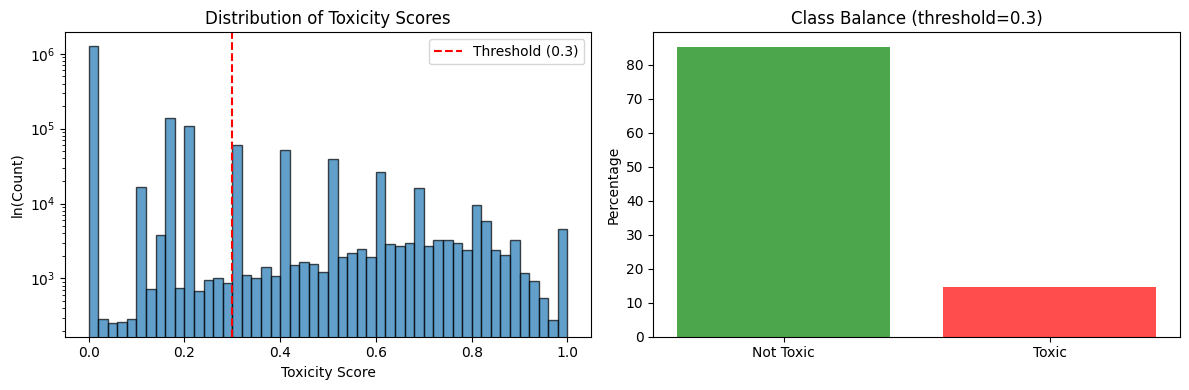

At threshold 0.3: 14.7% toxic, 85.3% not toxic


In [5]:
# Now let's see the distributions of the scores
train_toxicity = np.array(dataset['train']['toxicity'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
# nonzero_toxicity = train_toxicity[train_toxicity > 0] # Exclude zero-toxicity mass for visualization clarity
axes[0].hist(train_toxicity, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(config.toxic_threshold, color='red', linestyle='--', label=f'Threshold ({config.toxic_threshold})')
axes[0].set_xlabel('Toxicity Score')
axes[0].set_ylabel('ln(Count)')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Toxicity Scores')
axes[0].legend()

# Class balance at our threshold
toxic_pct = (train_toxicity >= config.toxic_threshold).mean() * 100
axes[1].bar(['Not Toxic', 'Toxic'], [100-toxic_pct, toxic_pct], color=['green', 'red'], alpha=0.7)
axes[1].set_ylabel('Percentage')
axes[1].set_title(f'Class Balance (threshold={config.toxic_threshold})')

plt.savefig(f'{config.figures_dir}/data_distribution.png', dpi=300)
plt.tight_layout()
plt.show()



print(f"At threshold {config.toxic_threshold}: {toxic_pct:.1f}% toxic, {100-toxic_pct:.1f}% not toxic")

The data is actually made up of two distributions with most comments being not toxic:
- Many low toxicity, cheaply annotated comments that have more discrete intervals
- Some high toxicity, heavily reviewed comments that seem to be averaged out amongst many reviewers

Some of the lines are binning artifacts but because there are over a hundred times more decile labels than in between for scores such as 0.2, this explanation makes more sense. I also had to make the y-axis logarithmic to show scores like 0 without distorting the high toxicity distribution.

Since we will be training the model for binary outputs, we have to choose the toxicity level we want to split the data from "toxic" and "not toxic". Above the toxicity threshold, we will call a label "toxic" and right below it we will call it "not toxic" It defines what our model thinks is toxic or not.

Choosing a toxicity threshold is probably one of the most important part of this pipeline. If we define a threshold where we let through comments with things we don't like, the model will classify them as not toxic and this will make our metrics look way better than what we wanted.

At some point in the pipeline, we have to eventually define a threshold of what's toxic or not anyways, let's pick 0.3 and see what kind of comments are around it.

Examples of comments:

In [6]:
# Sample comments to see what we're dealing with
print("Sample VERY TOXIC (> 0.8) comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] >= 0.8).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")

print("Sample ABOVE BOUNDARY (0.3 to 0.4)TOXIC comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] >= config.toxic_threshold and x['toxicity'] <= config.toxic_threshold+ .1).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")
print("Sample BELOW BOUNDARY (0.2 to 0.3)TOXIC comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] >= config.toxic_threshold -.1 and x['toxicity'] <= config.toxic_threshold).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")

print("\nSample NON-TOXIC (< 0.1)comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] < 0.1).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")

Sample VERY TOXIC (> 0.8) comments:
--------------------------------------------------
[0.89] haha you guys are a bunch of losers....

[0.91] Yet call out all Muslims for the acts of a few will get you pilloried.   So why is it okay to smear an entire religion o...

[0.83] This bitch is nuts. Who would read a book by a woman....

Sample ABOVE BOUNDARY (0.3 to 0.4)TOXIC comments:
--------------------------------------------------


Filter:   0%|          | 0/1804874 [00:00<?, ? examples/s]

[0.30] Mormons have had a complicated relationship with federal law....

[0.36] Send more dildos, STAT....

[0.30] I couldn't be more pleased. Comments on many sites too often get overtaken by trolls. It's the first I've heard of Civil...

Sample BELOW BOUNDARY (0.2 to 0.3)TOXIC comments:
--------------------------------------------------


Filter:   0%|          | 0/1804874 [00:00<?, ? examples/s]

[0.20] I'm crazy about that illustration! I never would have thought to pitch everything so yellow and orange....

[0.20] Thank you, thank you, thank you! I love WW content but the comment section has polluted for far too long. The lack of co...

[0.20] I think Native Americans should get a pass for being suspicious of any part of this government for the next… forever....


Sample NON-TOXIC (< 0.1)comments:
--------------------------------------------------
[0.00] This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!...

[0.00] Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!...

[0.00] This is such an urgent design problem; kudos to you for taking it on. Very impressive!...



After checking the comments right above and right below where annotators rated toxicity a 0.3, this threshold looks good. Right above a toxicity threshold of 0.3, we get comments sarcastic comments about Mormons, dildos, and trolls. I would not want any of that for my [kid safe mode](#kidsafemode).

Eventually we need to discretize into "allow", "remove", and possibly even "review" bins. Seems like the toxicity threshold of around 0.3 is pretty decent but it's somewhat an arbitrary hyperparameter depending on how strict you want to be. We'll get to why this wouldn't be a problem if we pick the right metric in a bit but let's look at some graphs first.

## Evaluation Methods

### The Naive Method
The naive way to score the models would be to see how accurately it matches the distribution we fed in. (For example, does the output model mark 85.3% percent of the responses as nontoxic?)

This approach lacks dimensionality in proving that it understands and is easily reward hacked. The easiest way to achieve this would be to just literally mark every single response as "not toxic". This model will get 85.3% of the responses right.

### Why use Log-Probabilities as a Metric?

This score corresponds directly to the log-probability difference optimized by the DPO objective, making it a natural evaluation and decision metric.

$$
\text{score} = log(P(y = \text{toxic} \mid \text{prompt}))-log(P(y = \text{non-toxic} \mid \text{prompt}))
$$

Why probabilities? Since the LLM outputs a distribution of possible next words through logits, probability is an obvious choice.

Why log? Mapping to log space has the nice property of turning ratios into differences. By subtracting the log probabilities, the metric allows us to compare the relative confidence of two outputs. We have the nice extension of being able to also measure the confidence in the model's decisions.


Using some log rules we get:

$$
e^{\text{score}} = \frac{P(\text{"toxic"} \mid x)}{P(\text{"not toxic"} \mid x)}
$$

This score map our binary outcome into a continuous number going from -inf to inf that represents how many more times the model thinks the comment is "toxic" than "toxic" with:
- positive score = model thinks toxic
- negative score = model thinks not toxic
- magnitude of score = confidence

A score of 1 means the model is ~2.718(or e) times more confident that the answer is "toxic" vs "not toxic".

A score of -1 means the model is ~2.718(or e) times more confident that the answer is "not toxic" vs "toxic".

### Data Preparation

We need two dataset formats:
1. **SFT format**: `{prompt, completion}` pairs
2. **DPO format**: `{prompt, chosen, rejected}` triplets
   
We'll prepare the data so that the only output is "toxic" or "not toxic". We'll also keep the outputs lowercase for convenience.

**Complete SFT Format**

Is this comment toxic? Answer only 'toxic' or 'not toxic'.

Comment: What's your favorite day of the week?

Answer: not toxic

**Complete DPO Format**

Is this comment toxic? Answer only 'toxic' or 'not toxic'.

Comment: What's your favorite day of the week?

Answer: not toxic

Rejected: toxic

In [7]:
def format_sft_example(example, toxic_threshold=0.3):
    """Convert to SFT format with binary label."""
    label = 'toxic' if example['toxicity'] >= toxic_threshold else 'not toxic'
    prompt = (
        f"Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\n"
        f"Comment: {example['text']}\n\n"
        f"Answer:"
    )
    return {'prompt': prompt, 'completion': f' {label}'}


def format_dpo_example(example, toxic_threshold=0.3):
    """Convert to DPO format with chosen/rejected responses."""
    is_toxic = example['toxicity'] >= toxic_threshold
    prompt = (
        f"Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\n"
        f"Comment: {example['text']}\n\n"
        f"Answer:"
    )
    if is_toxic:
        return {'prompt': prompt, 'chosen': ' toxic', 'rejected': ' not toxic'}
    else:
        return {'prompt': prompt, 'chosen': ' not toxic', 'rejected': ' toxic'}

For SFT I picked 8k since it's just learning the output format. The base model itself already has decent language understanding. For DPO I picked slightly more at 10k because preference learning benefits from more examples, especially on borderline cases. The validation is not really needed but 1k should be enough for sanity checks.

Now let's actually prepare the datasets and store them. The final test set looks like the SFT format so we will be making that here as well:

In [8]:
# Prepare SFT datasets
train_sft = dataset['train'].shuffle(seed=config.seed).select(range(config.sft_train_samples))
train_sft = train_sft.map(lambda x: format_sft_example(x, config.toxic_threshold), 
                          remove_columns=dataset['train'].column_names)

eval_sft = dataset['validation'].shuffle(seed=config.seed).select(range(config.sft_eval_samples))
eval_sft = eval_sft.map(lambda x: format_sft_example(x, config.toxic_threshold),
                      remove_columns=dataset['validation'].column_names)

# For final testing and analysis
test = dataset['test'].shuffle(seed=config.seed).select(range(config.test_samples))
test = test.map(lambda x: format_sft_example(x, config.toxic_threshold),
                      remove_columns=dataset['test'].column_names)

# Save for later
train_sft.to_json(os.path.join(config.data_dir, 'civil_comments_sft_train.jsonl'))
eval_sft.to_json(os.path.join(config.data_dir, 'civil_comments_sft_eval.jsonl'))
test.to_json(os.path.join(config.data_dir, 'civil_comments_test.jsonl'))

print(f"SFT train: {len(train_sft):,} | SFT eval: {len(eval_sft):,}| Test: {len(test):,}")
print(f"\nSample: {train_sft[0]}")

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Creating json from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/40 [00:00<?, ?ba/s]

SFT train: 8,000 | SFT eval: 1,000| Test: 40,000

Sample: {'prompt': "Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\nComment: Nope, move the business to the US, live in Erie.  Pretty simple really, best of both worlds, keep my money and live in Canada. \n\nI guess that's too hard for a civil servant to figure out.\n\nAnswer:", 'completion': ' not toxic'}


In [9]:
# Prepare DPO datasets
train_dpo = dataset['train'].shuffle(seed=config.seed+1).select(range(config.dpo_train_samples))
train_dpo = train_dpo.map(lambda x: format_dpo_example(x, config.toxic_threshold),
                          remove_columns=dataset['train'].column_names)

eval_dpo = dataset['validation'].shuffle(seed=config.seed+2).select(range(config.dpo_eval_samples))
eval_dpo = eval_dpo.map(lambda x: format_dpo_example(x, config.toxic_threshold),
                      remove_columns=dataset['validation'].column_names)

train_dpo.to_json(os.path.join(config.data_dir, 'civil_comments_dpo_train.jsonl'))
eval_dpo.to_json(os.path.join(config.data_dir, 'civil_comments_dpo_eval.jsonl'))

print(f"DPO train: {len(train_dpo):,} | DPO eval: {len(eval_dpo):,}")
print(f"\nSample: {train_dpo[0]}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Creating json from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

DPO train: 10,000 | DPO eval: 1,000

Sample: {'prompt': "Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\nComment: KKK + Nazi's = President winner winner chicken dinner.\n\nAnswer:", 'chosen': ' not toxic', 'rejected': ' toxic'}


Nice, that's the format we wanted.

Now let's see what the untrained LLaMA wants to output after the prompt:

In [10]:
# Load base model
model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(config.model_id)
tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded {config.model_id}")
print(f"Parameters: {model.num_parameters():,}")

Loaded meta-llama/Llama-3.2-1B-Instruct
Parameters: 1,235,814,400


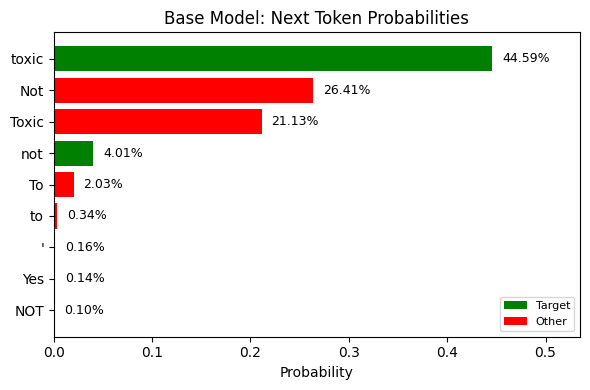

Base model: P(toxic)=0.4459, P(not)=0.0401, sum=0.4860


In [11]:
from src.scoring import plot_top_token_probs, get_label_probs

# Test on sample prompt
sample_prompt = eval_sft[0]['prompt']

# Base model
fig = plot_top_token_probs(model, tokenizer, sample_prompt, title="Base Model: Next Token Probabilities")
plt.savefig(f'{config.figures_dir}/base_token_probs.png', dpi=150)
plt.show()

# Print the probability of labels
p_toxic, p_not = get_label_probs(model, tokenizer, sample_prompt)
print(f"Base model: P(toxic)={p_toxic:.4f}, P(not)={p_not:.4f}, sum={p_toxic+p_not:.4f}")

The base model’s probability mass is spread across vocabulary. The next token is not what we want in more than half of the cases, confirming the need for finetuning.

## SFT Training

First, let's clear our VRAM and load something with better memory management:

In [12]:
def clear_memory():
    """Clear GPU memory between training runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

clear_memory()

Hardware constraints of 8GB VRAM required 4-bit quantization, which reduced memory usage by 3-4x than 16-bit. I used NF4 because model weights are gaussian and it has a higher resolution near zero.

In [13]:
# RTX 4070 only has 8GB, let's do calculations in 4bit to conserve memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type=config.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=config.bnb_4bit_use_double_quant
)

tokenizer = AutoTokenizer.from_pretrained(config.model_id, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load the model
model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
model = prepare_model_for_kbit_training(model)

print(f"Loaded {config.model_id}")
print(f"Parameters: {model.num_parameters():,}")

Loaded meta-llama/Llama-3.2-1B-Instruct
Parameters: 1,235,814,400


The LoRA adapter is what makes it possible to train this on a laptop. It keeps the base model the same but we finetune an adapter that we can add on to the base model. We use an adapter with a rank of 16 which is standard for a 1B model and has a good quality to memory tradeoff.

Another great setting to conserve memory is to reduce the per device batch size. We calculate the gradient one at a time but end up averaging 16 gradients at a time by accumulating them. This simulates a batch size of 16 without the additional memory cost.

In [14]:
# LoRA config, only train attention projections
lora_config = LoraConfig(
    r=config.lora_r,
    lora_alpha=config.lora_alpha,
    lora_dropout=config.lora_dropout,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=list(config.lora_target_modules)
)

# SFT training config
sft_config = SFTConfig(
    output_dir=config.sft_output_dir,
    num_train_epochs=config.sft_epochs,
    per_device_train_batch_size=config.sft_batch_size,
    gradient_accumulation_steps=config.sft_gradient_accumulation,
    learning_rate=config.sft_learning_rate,
    warmup_ratio=config.sft_warmup_ratio,
    max_length=config.sft_max_length,
    packing=False,
    logging_steps=10,
    save_steps=100,
    save_total_limit=5,
    bf16=True,
    optim='paged_adamw_8bit',
    report_to='none',
    seed=config.seed
)

print(f"Effective batch size: {config.sft_batch_size * config.sft_gradient_accumulation}")

Effective batch size: 16


8k examples is more than enough for teaching our model the simple format with SFT.

In [15]:
# Load SFT data
train_sft = load_dataset('json', data_files='data/civil_comments_sft_train.jsonl', split='train')
eval_sft = load_dataset('json', data_files='data/civil_comments_sft_eval.jsonl', split='train')

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_sft,
    eval_dataset=eval_sft,
    peft_config=lora_config,
    processing_class=tokenizer,
)

print(f"Training on {len(train_sft):,} examples")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Training on 8,000 examples


In [16]:
# Train!
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,0.751000
20,0.186800
30,0.163000
40,0.193300
50,0.126700
60,0.149000
70,0.125900
80,0.107900
90,0.179900
100,0.159200


TrainOutput(global_step=500, training_loss=0.11738197171688079, metrics={'train_runtime': 1826.0815, 'train_samples_per_second': 4.381, 'train_steps_per_second': 0.274, 'total_flos': 4160336766824448.0, 'train_loss': 0.11738197171688079})

### Training Observations

Training loss plateaus within in about 80 steps, showing rapid convergence on the core decision boundary.

I tested with longer training and more data but gains flattened quickly. This is a good sign we need to change strategies. Let's save first:

In [17]:
# Save the adapter
trainer.model.save_pretrained(config.sft_adapter_path)
tokenizer.save_pretrained(config.sft_adapter_path)
print(f"Saved SFT adapter to {config.sft_adapter_path}")

Saved SFT adapter to ../civil-toxicity-artifacts/checkpoints/sft/final


In [18]:
clear_memory()

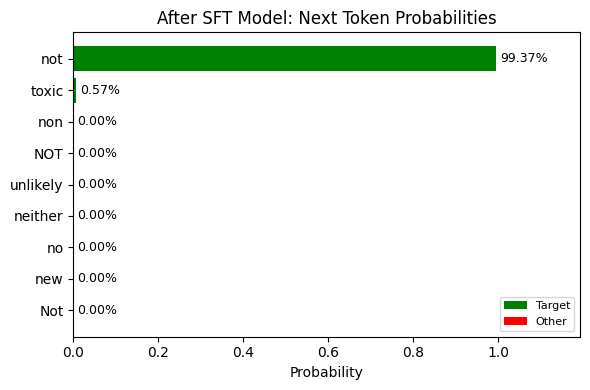

SFT model: P(toxic)=0.0057, P(not)=0.9937, sum=0.9994


In [19]:
from src.scoring import plot_top_token_probs

sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
sft_model = PeftModel.from_pretrained(sft_base, config.sft_adapter_path)

# Test on sample prompt
sample_prompt = eval_sft[0]['prompt']

# Base model
fig = plot_top_token_probs(sft_model, tokenizer, sample_prompt, title="After SFT Model: Next Token Probabilities")
plt.savefig(f'{config.figures_dir}/sft_token_probs.png', dpi=150)
plt.show()

# Print the probability of labels
p_toxic, p_not = get_label_probs(sft_model, tokenizer, sample_prompt)
print(f"SFT model: P(toxic)={p_toxic:.4f}, P(not)={p_not:.4f}, sum={p_toxic+p_not:.4f}")

clear_memory()

#### Log-Odds

After SFT, probability mass concentrates almost entirely on the two label token under the training prompt:
$$ P(\text{"toxic"}\mid prompt) + P(\text{"not toxic"}\mid prompt) \approx 1 $$

This is not explicity enforced buy the loss, but is a direct consequence of training on two labels. Under this prompt, the model now behaves like a binary classifier, with other continuation receiving negligible probability. If we did not do SFT before, DPO would be inefficient because its job isn't to learn the statistical probability of seeing "toxic" vs "not toxic", its objective is to increase the log-probability difference between the two tokens.

A useful consequence of this is that the log-probability difference between the two labels can be interpreted as a log-odds score for this interface. I later discuss why extending this interpretation beyond the training prompt can be misleading in calibration analysis.

## DPO Training
DPO has a nice side effect of optimizing the same log-prob difference we use for scoring. It's also sample and compute efficient. 

$$\text{score} = log(P(\text{toxic}\mid \text{comment})) - log(P(\text{not toxic}\mid \text{comment}))$$

The resulting optimization dynamics are analogous to logistic regression on preference margins. Updates are largest near the decision boundary and diminish as the difference between them grow. 

The beta parameter controls how aggressively preference margins are enforced before the objective saturates. 
- higher values correct violations quickly but shut off learning early
- lower values preserve a wider active margin and produce smoother confidence shaping

In practice, beta should be chosen based on data availibility, compute budget, and label noise. With enough high quality data, lower beta is preferable as it allows margins to keep growing for longer before saturation longer resulting in a larger final seperation. 

In [4]:
# Load DPO datasets
train_dpo = load_dataset('json', data_files='data/civil_comments_dpo_train.jsonl', split='train')
eval_dpo = load_dataset('json', data_files='data/civil_comments_dpo_eval.jsonl', split='train')

print(f"DPO train: {len(train_dpo):,} | DPO eval: {len(eval_dpo):,}")

DPO train: 10,000 | DPO eval: 1,000


In [5]:
clear_memory()

# let's do calculations in 4bit to conserve memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type=config.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=config.bnb_4bit_use_double_quant
)

# Load SFT model as starting point for DPO
sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=torch.float16
)

sft_base = prepare_model_for_kbit_training(sft_base)
sft_model = PeftModel.from_pretrained(sft_base, config.sft_adapter_path, is_trainable=True)
sft_model.print_trainable_parameters()

tokenizer = AutoTokenizer.from_pretrained(config.model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

trainable params: 3,407,872 || all params: 1,239,222,272 || trainable%: 0.2750


We use beta=0.1 for this notebook. A seperate notebook performs a beta sweep since DPO performance is sensitive to this hyperparameter.

In [22]:
# DPO config
dpo_config = DPOConfig(
    output_dir=config.dpo_output_dir,
    num_train_epochs=config.dpo_epochs,
    per_device_train_batch_size=config.dpo_batch_size,
    gradient_accumulation_steps=config.dpo_gradient_accumulation,
    learning_rate=config.dpo_learning_rate,
    beta=config.dpo_beta,  # KL penalty
    max_length=config.dpo_max_length,
    max_prompt_length=config.dpo_max_prompt_length,
    logging_steps=10,
    save_steps=100,
    fp16=True,
    gradient_checkpointing=False,
    report_to='none',
)

dpo_trainer = DPOTrainer(
    model=sft_model,
    ref_model=None,  # Uses initial SFT weights as reference
    args=dpo_config,
    train_dataset=train_dpo,
    eval_dataset=eval_dpo,
    processing_class=tokenizer,
)

print(f"Beta (KL penalty): {config.dpo_beta}")

Extracting prompt in train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Extracting prompt in eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Beta (KL penalty): 0.1


In [23]:
# Train DPO
dpo_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.
C:\Users\danie\anaconda3\envs\llm\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
C:\Users\danie\anaconda3\envs\llm\lib\site-packages\torch\utils\checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss
10,0.428100
20,0.291500
30,0.245900
40,0.178100
50,0.170900
60,0.338600
70,0.233400
80,0.258400
90,0.284900
100,0.343900


C:\Users\danie\anaconda3\envs\llm\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
C:\Users\danie\anaconda3\envs\llm\lib\site-packages\torch\utils\checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
C:\Users\danie\anaconda3\envs\llm\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default

TrainOutput(global_step=625, training_loss=0.24274262256622314, metrics={'train_runtime': 2711.785, 'train_samples_per_second': 3.688, 'train_steps_per_second': 0.23, 'total_flos': 0.0, 'train_loss': 0.24274262256622314, 'epoch': 1.0})

Save the adapter, this contains both the SFT and the DPO weights.

In [24]:
# Save DPO adapter
dpo_trainer.save_model(config.dpo_adapter_path)
tokenizer.save_pretrained(config.dpo_adapter_path)
print(f"Saved DPO adapter to {config.dpo_adapter_path}")

Saved DPO adapter to ../civil-toxicity-artifacts/checkpoints/dpo/final


In [6]:
clear_memory()

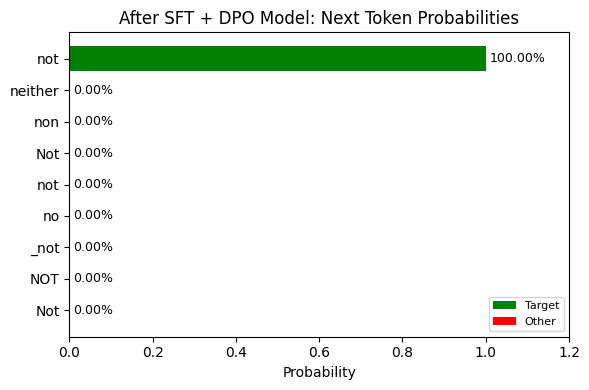

AFter SFT + DPO model: P(toxic)=0.0000, P(not)=1.0000, sum=1.0000


In [5]:
from src.scoring import plot_top_token_probs
from src.scoring import get_label_probs
clear_memory()

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.dpo_adapter_path)

# Load base model
base_model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    dtype=torch.float16,
    device_map='auto'
)

# Load adds our SFT + DPO adapter
dpo_model = PeftModel.from_pretrained(base_model, config.dpo_adapter_path)

# Turning off gradient checkpointing for evals
dpo_model.eval()

# Test on sample prompt
eval_sft = load_dataset('json', data_files='data/civil_comments_sft_eval.jsonl', split='train')
sample_prompt = eval_dpo[0]['prompt']

# Plot
fig = plot_top_token_probs(dpo_model, tokenizer, sample_prompt, title="After SFT + DPO Model: Next Token Probabilities")
plt.savefig(f'{config.figures_dir}/dpo_token_probs.png', dpi=300)
plt.show()

# Print the probability of labels
p_toxic, p_not = get_label_probs(dpo_model, tokenizer, sample_prompt)
print(f"AFter SFT + DPO model: P(toxic)={p_toxic:.4f}, P(not)={p_not:.4f}, sum={p_toxic+p_not:.4f}")
clear_memory()

Early after SFT, the distribution is close to log-odds, with label tokens dominating. With extended DPO training, the model becomes nearly deterministic and the log-odds interpretation breaks down. In practice, DPO mainly reduces uncertainty around borderline cases, increasing separation without materially changing accuracy.

**Limitation:** DPO produces overconfident predictions (P ≈ 0 or 1, rarely in between). This is fine for ranking or thresholding but means the raw probabilities shouldn't be interpreted as calibrated confidence.

# Evaluation (Run this only once)

Now, we will evaluate our models one at a time on the test data set, making sure to save the data and clear the memory when we are done with each model. We remove 4 bit quantization for evaluation purposes, the equation should only use around 5.5 GB of VRAM.

The 'results.csv' files will save three things: 
1. The prompt
2. If annotators labeled it above a toxicity score of 0.3
3. The log-probability score that each model outputs when given the prompt

We save the data into out results directory for easy access.

#### How many data points?

When I first evaluated the model, I used only 1,000 samples and many of the curves had low resolution especially on the left side of the PR diagram which was jagged. There would not be as many data points since only the most toxic examples are flagged. For this notebook, I analyzed 40,000 for clean graphs but I've found 10k samples works fairly well with diminishing returns past 20k samples.

Let's also make sure we get the test data ready.

In [7]:
import src.scoring
from src.scoring import evaluate_model

# Load test eval data
test = load_dataset('json', data_files='data/civil_comments_test.jsonl', split='train')

# Tokenizer for all models
tokenizer = AutoTokenizer.from_pretrained(config.model_id)

Since we are not training anymore, we will drop the 4 bit quantization and go back to float16.

In [5]:
# Evaluate BASE model first
clear_memory()

print("Evaluating BASE model...")
base_model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    dtype=torch.float16,
    device_map='auto'
)

# Disable dropout layers for evals
base_model.eval()

df_base = evaluate_model(base_model, tokenizer, test, max_samples=config.test_samples)
df_base.to_csv(Path(config.results_dir) / 'base_results.csv', index=False)

del base_model
clear_memory()

Evaluating BASE model...


NameError: name 'tokenizer' is not defined

In [30]:
# Evaluate SFT model
print("Evaluating SFT model...")

sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    dtype=torch.float16,
    device_map='auto'
)
sft_model = PeftModel.from_pretrained(sft_base, config.sft_adapter_path)

# Disable dropout layers for evals
sft_model.eval()

df_sft = evaluate_model(sft_model, tokenizer, test, max_samples=config.test_samples)
df_sft.to_csv(Path(config.results_dir) / 'sft_results.csv', index=False)

del sft_base, sft_model
clear_memory()

Evaluating SFT model...


Evaluating: 100%|██████████████████████████████████████████████████████████████| 40000/40000 [1:09:43<00:00,  9.56it/s]


In [8]:
# Evaluate DPO model
clear_memory()

print("Evaluating DPO model...")

# Load base model to attach with SFT
base_model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    dtype=torch.float16,
    device_map='auto'
)

# Load adds our SFT + DPO adapter
dpo_model = PeftModel.from_pretrained(base_model, config.dpo_adapter_path)

# Turning off gradient checkpointing for evals
dpo_model.eval()

# Run without storing activation graphs to save VRAM
with torch.no_grad():
    df_dpo = evaluate_model(dpo_model, tokenizer, test, max_samples=config.test_samples)

df_dpo.to_csv(Path(config.results_dir) / 'dpo_results.csv', index=False)

del base_model, dpo_model
clear_memory()

Evaluating DPO model...


Evaluating: 100%|████████████████████████████████████████████████████████████████| 40000/40000 [49:15<00:00, 13.54it/s]


NameError: name 'sft_base' is not defined

In [14]:
clear_memory()

## Analysis

**Note**: All scoring imports loaded in initial imports

Let's load in our saved evaluation data for each model:

In [10]:
# Load in saved Dataframes
df_base = pd.read_csv(Path(config.results_dir) / 'base_results.csv')
df_sft = pd.read_csv(Path(config.results_dir) / 'sft_results.csv')
df_dpo = pd.read_csv(Path(config.results_dir) /'dpo_results.csv')

The compute_metrics function puts our data into different sklearn functions that will help us calculate our PR and ROC curves easily by sweeping through thresholds of our log-probability scores.

In [11]:
# Compute metrics, Calculates PR-AUC, ROC-AUC, curves and operating points
metrics_base = compute_metrics(df_base)
metrics_sft = compute_metrics(df_sft)
metrics_dpo = compute_metrics(df_dpo)

### PR and ROC Curves

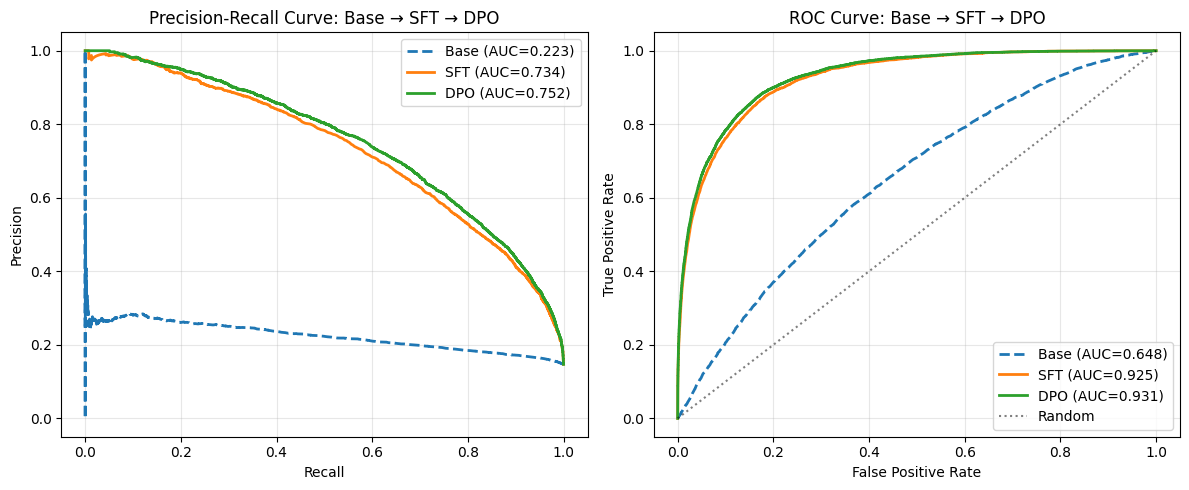

In [12]:
# Plot PR and ROC curves
fig = plot_all_curves(metrics_base, metrics_sft, metrics_dpo)
plt.savefig(f'{config.figures_dir}/all_curves.png', dpi=300)
plt.show()

Looking at both curves the base model went from being useless at classifying our definition of toxic to having a huge jump in area with just the SFT training. Adding DPO has refined the model and added a small boost to precision/recall and TP/FP trade offs on all possible thresholds.

### Precision Recall tradeoffs <a id="kidsafemode"></a>

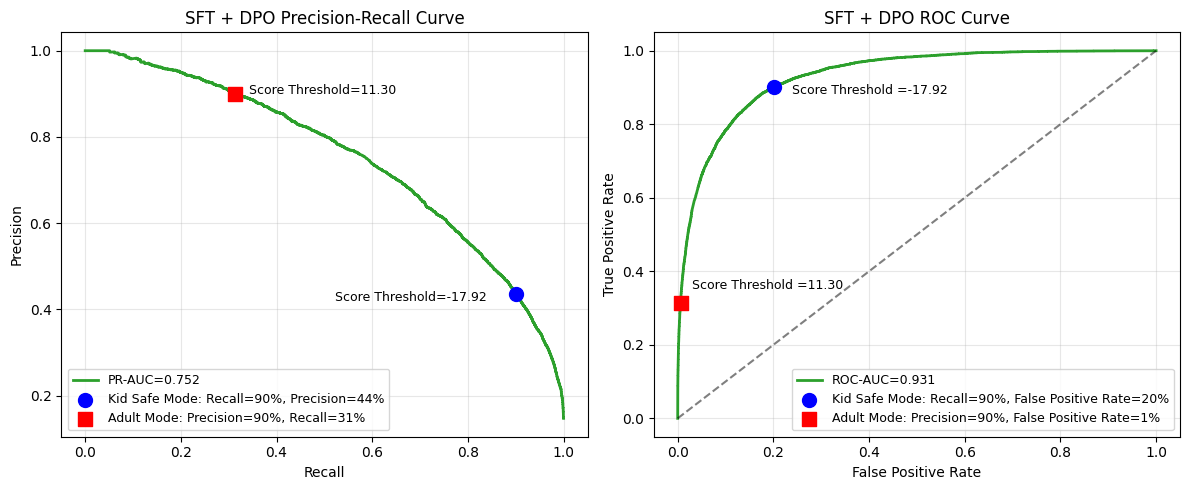

In [25]:
fig = plot_curves_with_operating_points(metrics_dpo, 'SFT + DPO ')
plt.savefig(f'{config.figures_dir}/DPO_operating_curves.png', dpi=300)
plt.show()

1. **Kid Safe Mode (90% recall)**: Minimize mixed toxicity. Catches 90% of toxic comments, but 56% of flags are false positives. Definitely a setting Roblox would like.
2. **Adult Mode (90% precision)**: Avoid unnecessary censorship. Is correct about toxic comments 90% of the time but only catches 31% of toxic content.

The score threshold gap (${\Delta} \approx 35$ log-probability) between the modes requires $e^{\Delta} \approx e^{35}\sim 10^{15}$ higher confidence before flagging. Changing the threshold allows us to use the same model but with a different policy.

**Note: Toxic comments defined as dataset score ≥ 0.3**

**Precision at Fixed Recall**
| Recall | Base | SFT | DPO |
|--------|------|-----|-----|
| 95% | 17% | 33% | 35% |
| 90% | 17% | 41% | 44% |
| 80% | 19% | 52% | 55% |

**Recall at Fixed Precision**
| Precision | Base | SFT | DPO |
|-----------|------|-----|-----|
| 95% | 0% | 17% | 21% |
| 90% | 0% | 26% | 31% |
| 80% | 0% | 46% | 51% |

On Kid Safe Mode (90% recall), DPO gains +2.4% precision over SFT.

On Adult Mode (90% precision), DPO gains +5.4% recall over SFT.

The base model is unable to detect any comments with a Precision above ~30%. Our score compares log P("toxic") vs log P("not toxic") and favors confidence. This indicates that the base model assigns similar probability to both labels, so the log-probability difference is noise. SFT concentrates probability on our labels, making the score meaningful.

### Score Distributions

Mean shift for TOXIC comments:     +2.5769
Mean shift for NOT TOXIC comments: -24.1299

Ideal: Toxic shifts positive, Not Toxic shifts negative


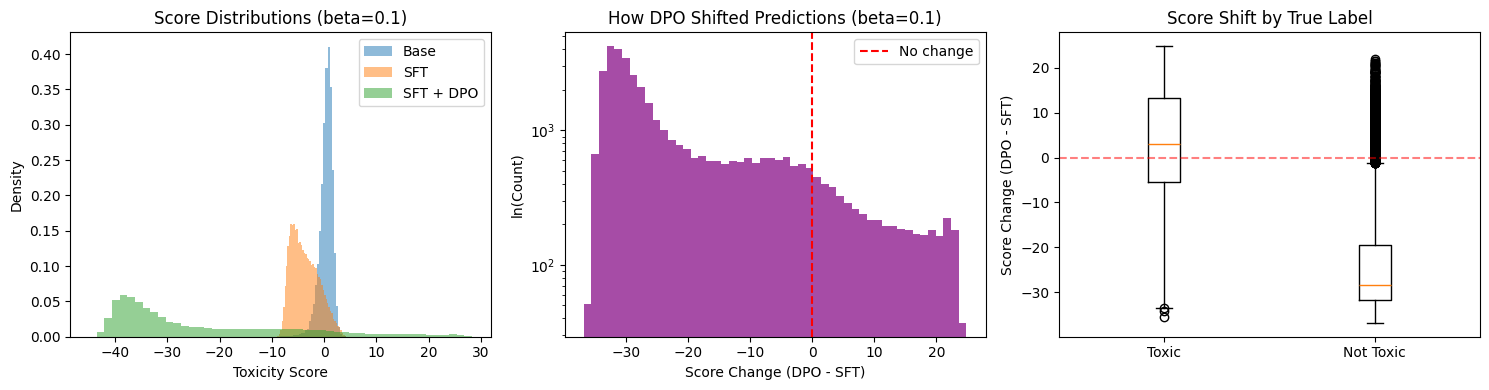

In [66]:
scoring.plot_score_distributions(df_sft, df_dpo, df_base=df_base, beta=config.dpo_beta) # Note: base is the third argument since it's optional
plt.savefig(f'{config.figures_dir}/score_distributions.png', dpi=300)

plt.show()

The mean score for toxic comments went up by ~2 and the mean score for "not toxic" comments went down by -24. Mathematicaly, this means DPO helped the model categorize "toxic" comments e^2 times more confidently and "not toxic" comments e^24 times more confidently. 

This indicates DPO primarily learned to be much more confident about what isn't toxic, which reduces false positives more than it reduces false negatives.

Comparing the original dataset toxicity scores with the model scores after SFT and DPO, the overall shape of the distribution remains similar. Preference optimization largely preserves the underlying ordering of examples, acting as a mostly monotonic remapping rather than learning a new notion of toxicity. DPO primarily increases margin and confidence, pushing ambiguous examples away from the decision boundary without reshuffling the extremes.

### Biggest Scores Changes after DPO

In [14]:
find_biggest_changes(df_sft, df_dpo, n=10)


TOP 10 EXAMPLES WHERE DPO CHANGED MOST

✓ True: not toxic | SFT: -7.55 → DPO: -44.37 (↓ less toxic)
   Lou Skizas wrote: "Those details have all been reported before..."

Perhaps you have a link to the story I missed, that spells out the specifics of ou...

✓ True: not toxic | SFT: -7.66 → DPO: -44.28 (↓ less toxic)
   FACT CHECK REQUESTED !

Anita
Sorry, you guys are the 3rd organization I have seen so far to simply repeat this statement - that shelter beds are goin...

✓ True: not toxic | SFT: -6.41 → DPO: -42.87 (↓ less toxic)
   Using debt strategically by getting a credit card to finance a wedding.
'Strategically'?
'use the points he earns from that to then help cover the cos...

✓ True: not toxic | SFT: -5.75 → DPO: -42.22 (↓ less toxic)
   (continued)

Staff claims the WG permit has not actually been approved since other land use actions (i.e., the Planned Unit Development) are under app...

✓ True: not toxic | SFT: -8.48 → DPO: -44.93 (↓ less toxic)
   So what are they talking

,text,true_label,score_sft,score_dpo,score_diff,abs_diff
5434,"Lou Skizas wrote: ""Those details have all been...",0,-7.545861,-44.374283,-36.828422,36.828422
11246,"FACT CHECK REQUESTED !\n\nAnita\nSorry, you gu...",0,-7.655246,-44.280393,-36.625147,36.625147
15406,Using debt strategically by getting a credit c...,0,-6.408035,-42.874829,-36.466794,36.466794
33984,(continued)\n\nStaff claims the WG permit has ...,0,-5.750252,-42.216324,-36.466072,36.466072
36088,So what are they talking about? The City has ...,0,-8.483893,-44.931927,-36.448034,36.448034
15199,I went to a Neighborhood Board meeting last ni...,0,-5.813007,-42.249440,-36.436432,36.436432
14420,That's not what the article says. How would y...,0,-6.513796,-42.872698,-36.358902,36.358902
39834,Yes because most on your list are nothing burg...,0,-4.373596,-40.718288,-36.344692,36.344692
19737,Good questions Bob. We have been trying to sel...,0,-7.858728,-44.031042,-36.172315,36.172315
33418,Not sure what you source for news Joe but I do...,0,-4.937752,-41.093279,-36.155528,36.155528


The largest DPO score shifts occur on borderline comments that appear hostile but are non-toxic. DPO increased confidence in these prompts 10-15x compared to SFT bringing scores from ~-3 to ~-40. DPO learns to suppress stylistic aggression as a proxy for toxicity, pushing such examples far from the decision boundary. 

Again, DPO increases the model's confidence in its labels by shifting the distribution of scores leftward.

### Calibration

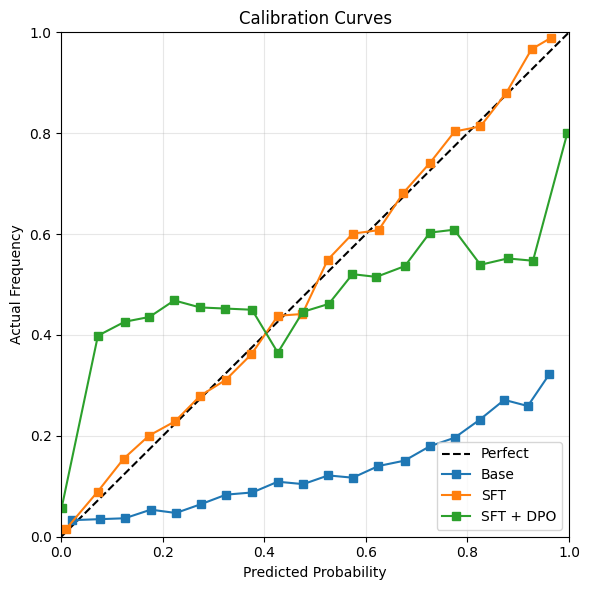

In [16]:
plot_all_calibration_curves(df_base, df_sft, df_dpo, n_bins=20)
plt.savefig(f'{config.figures_dir}/calibration_curves.png', dpi=300)
plt.show()

SFT produces well-calibrated probabilities. DPO sacrifices calibration for better ranking, it optimizes preference margin, teaching it more than the underlying statistics between words. This is evident when the DPO Actual Frequency hovers around 50% but this is not a problem with our log-probability scoring.

For deployment, use the score for ranking/thresholding, not as a literal probability. This is why we have to use DPO as a ranker.

**Calibration Note:** DPO improves ranking but degrades probability calibration. Scores should be interpreted as decision margins, not probabilities.

### Failure Analysis

In [17]:
raw = load_dataset('google/civil_comments', split='test')
fp, fn = failure_analysis(df_dpo, metrics_dpo['kid_safe_threshold'], raw_dataset=raw)


FAILURE ANALYSIS

--- FALSE POSITIVES (flagged but not toxic) ---

Model Score: 24.70 | Original Toxicity: 0.20
   I'm waiting for the column on Mika and Joe calling the President "moron", "idiot", "mentally unstable" and "shmuck". Will I be waiting long?...

Model Score: 24.28 | Original Toxicity: 0.17
   I'm assuming you are a child or perhaps just not up to speed on the planet. Do you actually think less people will die if you ban all guns ? The gangs...

Model Score: 23.97 | Original Toxicity: 0.27
   Try reporting what happens...not what you worry is going to happen....you asshats...

Model Score: 23.84 | Original Toxicity: 0.20
   Right, EVERYONE knows Putrumpski is a cretinous bully, so let's just accept it and move on. Nope....

Model Score: 23.42 | Original Toxicity: 0.00
   Heard my wife and a female friend talking the other day. One said: "Y'know, the problem with men is that they think that they should never change thei...

--- FALSE NEGATIVES (missed toxic content) ---

M

**False Positives** (flagged but labeled non-toxic):

| Comment | Model | Original | Analysis |
|---------|-------|----------|----------|
| "your stu*pidity is excused" | 27.4 | 0.16 | Toxic, mislabeled |
| "Colonel Sanders aka Dimwit" | 29.8 | 0.18 | Toxic, mislabeled |
| "Dumb French Liberals..." | 27.3 | 0.28 | Borderline |
| "Pollution EXISTS...severely stupid" | 27.8 | 0.17 | Triggered by "stupid" |

Most false positives contain clear insults that annotators scored too low. The model may be outperforming the labels.

**False Negatives** (missed but labeled toxic):

| Comment | Model | Original | Analysis |
|---------|-------|----------|----------|
| "not a legal thing yet..." | -40.7 | 0.30 | Benign, mislabeled |
| "The Changs let the theatre..." | -38.9 | 0.40 | Critical but mild |
| European wheat/Africa discussion | -38.8 | 0.40 | Long, requires context |
| "Go look it up in the dictionary" | -38.1 | 0.30 | Condescending, borderline |

False negatives cluster at 0.30-0.40 - the noisy boundary region.

Note: The score reflects relative log-odds, not absolute confidence. A low score means non-toxic dominates, but doesn't mean zero toxic signal.

Takeaway: For kid safe mode, these errors are acceptable. False positives are arguably correct, false negatives are mild.

Many of the False Positives are arguably correct and false negatives are mild. Probability analysis confirms the model is confident in these cases, not uncertain, suggesting label noise.



### Slice Analysis
RLHF changes the model's preferences for slices since it changes a model's behavior asymmetrically, making slice analysis important. The biases in our data show up best during slice analysis. I evaluated performance across slices: profanity, quotes, laughter, ALL CAPS, and length.

In [19]:
import importlib
import src.scoring

importlib.reload(src.scoring)
from src.scoring import slice_analysis_comparison
slice_results = slice_analysis_comparison(df_sft, df_dpo, metrics_sft['kid_safe_threshold'], metrics_dpo['kid_safe_threshold'] )
print(slice_results.to_string(index=False))

        slice     n  base_rate  sft_precision  sft_recall  dpo_precision  dpo_recall  precision_delta  recall_delta
has_profanity  4737   0.200549       0.452566    0.918947       0.476423    0.925263         0.023857      0.006316
   has_quotes 14295   0.153690       0.399877    0.888029       0.421963    0.888484         0.022086      0.000455
 has_laughter   407   0.216216       0.459770    0.909091       0.493750    0.897727         0.033980     -0.011364
    is_shouty    65   0.246154       0.500000    0.812500       0.520000    0.812500         0.020000      0.000000
      is_long  7660   0.142037       0.379019    0.866728       0.393092    0.878676         0.014073      0.011949
     is_short  4377   0.103267       0.389474    0.900442       0.435381    0.909292         0.045908      0.008850


Overall, DPO is increasing the precision as shown in the precision delta by about a percent or two while the recall remains the same.

In [20]:
merged = df_sft[['text', 'true_label', 'score']].merge(
    df_dpo[['text', 'score']], on='text', suffixes=('_sft', '_dpo'))
merged['shift'] = merged['score_dpo'] - merged['score_sft']

# Add slice flags
profanity = ['fuck', 'shit', 'damn', 'ass', 'bitch', 'hell']
merged['has_profanity'] = merged['text'].str.lower().str.contains('|'.join(profanity), regex=True)
merged['has_quotes'] = merged['text'].str.contains(r'["\'].*["\']', regex=True)
merged['has_laughter'] = merged['text'].str.lower().str.contains(r'\blol|lmao|haha\b', regex=True)
merged['is_shouty'] = merged['text'].str.isupper()
merged['is_long'] = merged['text'].str.len() > 500
merged['is_short'] = merged['text'].str.len() < 50

print(f"Overall mean shift: {merged['shift'].mean():.2f}")
for slice_name in ['has_profanity', 'has_quotes', 'has_laughter', 'is_shouty', 'is_long', 'is_short']:
    slice_data = merged[merged[slice_name]]
    shift = slice_data['shift'].mean()
    diff = shift - merged['shift'].mean()
    print(f"{slice_name:15} shift: {shift:6.2f} (vs avg: {diff:+.2f})")

Overall mean shift: -20.22
has_profanity   shift: -17.60 (vs avg: +2.61)
has_quotes      shift: -19.70 (vs avg: +0.52)
has_laughter    shift: -16.06 (vs avg: +4.16)
is_shouty       shift: -16.48 (vs avg: +3.74)
is_long         shift: -20.18 (vs avg: +0.03)
is_short        shift: -23.18 (vs avg: -2.96)


**Where DPO stays cautious:**
- `is_shouty` (ALL CAPS) - treated as aggression signal
- `has_laughter` - sarcastic toxicity ("lol you're an idiot") stays flagged
- `has_profanity` - no confidence boost even when benign

**Where DPO gains confidence:**
- `is_short` - less text, less ambiguity, largest shift toward non-toxic
- `has_quotes` - better handling of reported speech

Key finding: Recall stays stable across slices. DPO refines false positives, not false negatives. This aligns with the score shift analysis and DPO learned what is not toxic.

# Decision Policy Simulation: Turning Scores into Actions

Up to this point, everything has been analysis that measures how well the model scores content. This section covers what the system will do with the scores.

Policy lies between the score and the decision. The policy will map continuious risk scores to discrete outcomes using thresholds.
- ALLOW: Content passes automatically, no human sees it
- BLOCK: Content is removed or hidden automatically, no human needed
- ESCALATE: The model is not confident enough to decide. A human reviewer evaluates it.

**Constraints**

Recall can no longer be the primary decision metric once business constrainsts are introduced. We now want to measure how many toxic items leak through, FN (False Negative).

This system will be evaluated under two real world constraints:
1. Budget constrained: Review capacity is fixed. Given N human reviewers per day, what's the best safety outcome each model can achieve?
2. Risk-bounded: Safety requirements are fixed. Given a maximum accepetable FN rate, how much automation does each model deliver?

In [43]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load results
df_sft = pd.read_csv(Path(config.results_dir) / 'sft_results.csv')
df_dpo = pd.read_csv(Path(config.results_dir) / 'dpo_results.csv')

n_total = len(df_dpo)
n_toxic = df_dpo['true_label'].sum()
n_ntoxic = n_total - n_toxic
base_rate = n_toxic / n_total

print(f"Evaluation set: {n_total:,} comments | {n_toxic:,} toxic ({base_rate:.1%}) | {n_ntoxic:,} not toxic")

Evaluation set: 40,000 comments | 5,883 toxic (14.7%) | 34,117 not toxic


### 1. Running a Budget Constrained System

Human review capacity is fixed. A platform can review only N comments per day. The model's job is to triage: decide what to auto allow, what to auto block, and what to send to the fixed capacity review queue.

This simulation minimizes a weighted sum of two error types: toxic content that slips through auto allow (false negatives) and legitimate content that gets incorrectly auto blocked. 

The weight between them is a policy parameter, not a model parameter:
- Setting it high penalizes over censorship
- Setting it low penalizes missed toxicity

The model acts the same in both cases, only the decision rule changes. Without this combined penalty, the optimizer can reward hack by dumping all ambiguous content into auto block. 

In [61]:
from src.policy import run_budget_comparison, run_bootstrap_stability

budget_table = run_budget_comparison(df_sft, df_dpo, fn_fp_weight = .2)
budget_table.to_csv(Path(config.results_dir) / 'budget_constrained.csv', index=False)

BUDGET-CONSTRAINED ANALYSIS: SFT vs DPO at Fixed Review Capacity

Dataset: 40,000 comments | 5,883 toxic (14.7%)
Objective: minimize (5 × FN_in_allowed + FP_in_blocked) at fixed escalation budget
Question: At the same review budget, which model keeps users safer?

      Budget SFT Esc DPO Esc SFT FN% DPO FN%  SFT Missed  DPO Missed SFT Blk% DPO Blk% SFT BlkPrec DPO BlkPrec  SFT FP Blk  DPO FP Blk
  5% (2,000)   1,997   2,000   2.70%   2.57%         781         753    22.7%    21.9%       52.2%       54.5%        4332        3980
 10% (4,000)   3,998   4,000   2.56%   2.34%         733         673    18.5%    18.2%       58.9%       60.8%        3035        2856
 15% (6,000)   5,976   5,999   2.52%   2.34%         717         673    13.8%    13.2%       68.1%       71.0%        1761        1534
25% (10,000)   9,995  10,000   1.82%   1.70%         475         448     9.7%     9.2%       77.6%       80.3%         869         723

Esc        = comments sent to human review (should match bu

At every comment review budget level, DPO has less FN and higher precision. DPO consistently misses fewer toxic items than SFT at every budget level and the results scale smoothly across reasonable weight choices. Let's check how consistently DPO is better:

In [50]:
bootstrap_results = run_bootstrap_stability(df_sft, df_dpo, budget_frac=0.10)

Running 300 bootstrap resamples at 10% budget...

BOOTSTRAP STABILITY CHECK (n=300 resamples, budget=10%)

Δ Toxic Missed (DPO − SFT):
  Median: -175.0
  Mean:   -180.4
  95% CI: [-319.6, -14.0]
  Std:    88.1

Δ FN Rate (DPO − SFT):
  Median: -0.0046
  95% CI: [-0.0082, -0.0006]

DPO wins 296/300 resamples (99%)
Tie      0/300 resamples (0%)
SFT wins 4/300 resamples (1%)

→ DPO misses fewer toxic items at the same review budget.


In [44]:
compare_costs(df_sft, df_dpo, cost_ratios=[(10, 1), (5, 1), (1, 1), (1, 5)])


COST-SENSITIVE THRESHOLD ANALYSIS

FN:FP cost ratio 10:1
  SFT optimal: threshold=-2.688, cost=13213
  DPO optimal: threshold=-20.031, cost=12688
  Cost reduction: 525 (4.0%)

FN:FP cost ratio 5:1
  SFT optimal: threshold=-1.813, cost=9859
  DPO optimal: threshold=-14.482, cost=9396
  Cost reduction: 463 (4.7%)

FN:FP cost ratio 1:1
  SFT optimal: threshold=-0.039, cost=3721
  DPO optimal: threshold=0.735, cost=3573
  Cost reduction: 148 (4.0%)

FN:FP cost ratio 1:5
  SFT optimal: threshold=1.750, cost=5117
  DPO optimal: threshold=14.596, cost=4961
  Cost reduction: 156 (3.0%)


,fn_cost,fp_cost,sft_threshold,sft_cost,dpo_threshold,dpo_cost
0,10,1,-2.687561,13213.0,-20.031228,12688.0
1,5,1,-1.812988,9859.0,-14.481709,9396.0
2,1,1,-0.038859,3721.0,0.734619,3573.0
3,1,5,1.749525,5117.0,14.596239,4961.0


Cost-sensitive threshold analysis shows that DPO provides the largest gains under moderate FN:FP trade-offs (≈5:1), where policy decisions hinge on fine grained ranking among borderline cases. At extreme cost ratios, thresholds become dominated by policy constraints rather than model ordering, leaving little headroom for improvement. This behavior is expected for ranking-based optimization methods and is consistent with DPO primarily improving confidence separation rather than expanding achievable safety or permissiveness limits. DPO does not help uniformly, it helps most where policy decisions are ambiguous.

## 2. Running a Risk Bounded System

The constraints are flipped from before. Safety requirements are fixed. The platform mandates a maximum FN rate: no more than X% of auto allowed content can be toxic. Given that constraint, how much content can the system handle automatically?

This directly maps to:
- Kid Safe: FN <= 1% (strict)
- Default: FN <= 2% (moderate)
- Permissive FN <= 5% (relaxed)

In [65]:
from src.policy import run_risk_bounded_comparison

risk_table = run_risk_bounded_comparison(df_sft, df_dpo)
risk_table.to_csv(Path(config.results_dir) / 'risk_bounded.csv', index=False)

RISK-BOUNDED AUTOMATION: SFT vs DPO at Fixed Safety Constraints

Dataset: 40,000 comments | 5,883 toxic (14.7%)
Question: At the same safety guarantee, which model automates more?

              Policy SFT Auto-Rate DPO Auto-Rate Δ Auto SFT Escalated DPO Escalated SFT FN (actual) DPO FN (actual)
  Kid Safe (FN ≤ 1%)         97.7%         97.8% +0.1pp          2.3%          2.2%           0.99%           0.99%
   Default (FN ≤ 2%)         98.3%         98.4% +0.1pp          1.7%          1.6%           1.95%           2.00%
Permissive (FN ≤ 5%)         99.2%         99.2% -0.0pp          0.8%          0.8%           4.90%           4.96%

Auto-Rate = % of content decided without a human
Δ Auto = DPO improvement in automation (positive = DPO automates more)
Escalated = % sent to human review
FN (actual) = achieved FN rate (must stay ≤ policy constraint)


When bounded by risk, SFT and DPO achieve nearly identical automation rates. The delta column is 0.1pp or less across all three modes, which is effectively 0. This is consistent with the budget constrained finding. DPO's advantage is safety per reviewer by missing fewer missed toxic items at the same review budget. When you fix the safety bar, both models are good enough to auto resolve 97-99% of content. This makes sense since DPO improves when the decision boundary is difficult, not when you are operating in the extreme tail of the score distribution.

In [42]:
from src.policy import print_cost_impact

print_cost_impact(df_dpo, cost_low = 0.15 ,cost_high=0.40)

ILLUSTRATIVE COST IMPACT (upper-bound estimates)

Second-stage volume: 250,000 comments/day
Review cost: $0.15–$0.40 per comment

Kid Safe (FN ≤ 1%):
  244,437 auto-resolved / 5,563 escalated per day
  Review savings: $36,666–$97,775/day ($13,382,926–$35,687,802/year)
  Safety: FN rate 0.99% on auto-allowed content

Default (FN ≤ 2%):
  246,081 auto-resolved / 3,919 escalated per day
  Review savings: $36,912–$98,432/day ($13,472,935–$35,927,826/year)
  Safety: FN rate 2.00% on auto-allowed content

Permissive (FN ≤ 5%):
  247,912 auto-resolved / 2,088 escalated per day
  Review savings: $37,187–$99,165/day ($13,573,182–$36,195,152/year)
  Safety: FN rate 4.96% on auto-allowed content



## Lifecycle and Feedback Loop

This system does not learn online. The model is trained offline and deployed as a fixed scorer. Adaptation happens through three mechanisms:

1. Threshold tuning: if escalation volume creeps up or reviewers disagree, the platform can adjust the allow/block thresholds. No retraining is required. This is what seperating the scoring model from the decision policy allows us to do easily.

2. Targeted data augmentation: this addresses systematic slice failures. The slice analysis identified specific patterns where the model struggles such as sarcasm or political insults. If monitoring shows persistent errors in a slice, the examples are collected from the escalation queue and used to create the next round of DPO preeference pairs. The existing pipeline supports this without any architectural changes.

3. Model replacement is reserved for distribution shifts that threshold tuning can't absorb. The constraint based evaluation framework with the budget constrained and risk bounded tables provides a direct comparison protocol. Run the new model through the same analysis and check whether it improves safety at the same review budget.

Monitoring tracks decision level metrics such as: FN rate on auto allowed content, escalation rate, block precision, and slice level drift. Significant deviations trigger investigation instead of automatically updating.

## Summary
- SFT teaches the task and DPO refines the ranking. The result is a continuous score that can be thresholded for different policies such as kid-safe or adult mode without retraining.
- Two interpretable parameters control the system: the initial labeling threshold of 0.3 and the score threshold used at inference time. Both numbers are interpretable, auditable, and easily adjustable.
- DPO is most valuable when review capacity is the binding constraint (when the platform is scaling faster than it can hire trust and safety staff). When the binding constraint is a safety policy, both models deliver the same outcome.

## Future Work

- Beta sweep analysis across DPO hyperparameters (see `scripts/train_dpo.py` and `scripts/compare_runs.py`)
- Model distillation for cheaper, faster model
- Multi-label toxicity (threat, insult, obscenity)
- Compare to classification head baseline

## Reproducibility

All results in this report were generated by running the notebook `rlhf_content_moderation.ipynb` top-to-bottom with the provided configuration. A fixed random seed is used for all data splitting and model initialization. For DPO hyperparameter sweeps, use the CLI scripts:

```bash
python scripts/train_dpo.py --beta 0.1
python scripts/evaluate.py runs/dpo_beta_stability/<run_dir>/
python scripts/compare_runs.py runs/dpo_beta_stability/ --plot
```